In [2]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.image as img
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, log_loss



In [3]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")
test_outcome = pd.read_csv("data/gender_submission.csv")

test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
plt.style.use('seaborn-v0_8-whitegrid') 
matplotlib.rcParams.update({"font.size": 14})

train_data.Pclass = [str(i) for i in train_data.Pclass]

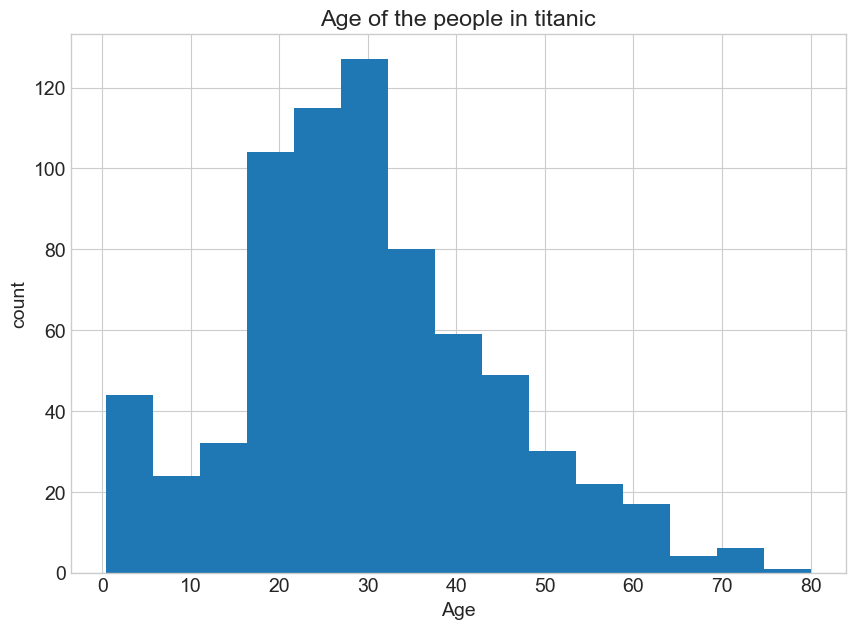

In [7]:
plt.figure(figsize=(10,7))

plt.hist(train_data.Age, bins=15)

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.show()

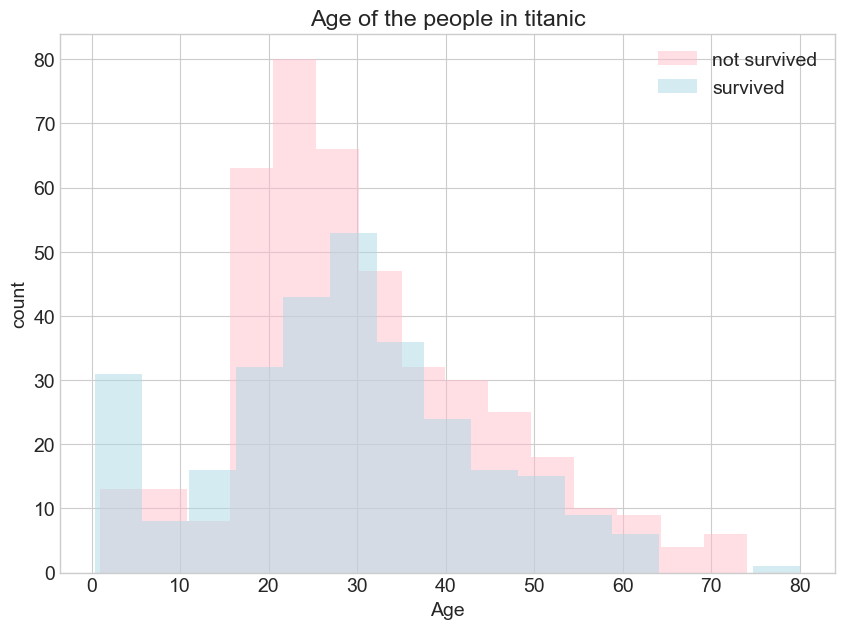

In [8]:
plt.figure(figsize=(10,7))

plt.hist(train_data.loc[train_data.Survived == 0]["Age"], alpha=0.5, bins=15, color="pink", label="not survived")
plt.hist(train_data.loc[train_data.Survived == 1]["Age"], alpha=0.5, bins=15, color="lightblue",label="survived")

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.legend()
plt.show()

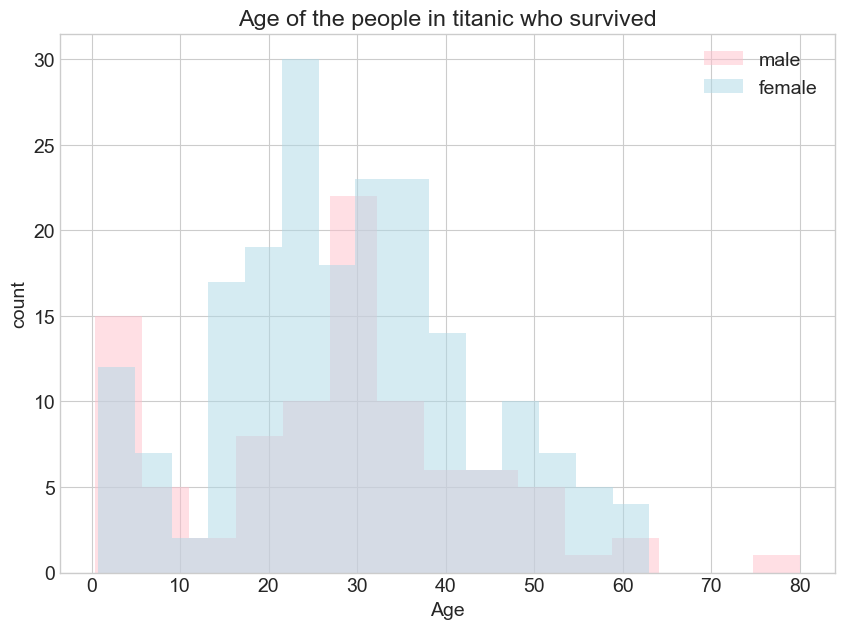

In [9]:
plt.figure(figsize=(10,7))

plt.hist(train_data.loc[(train_data.Survived == 1) & (train_data.Sex == "male")]["Age"], alpha=0.5, bins=15, color="pink", label="male")
plt.hist(train_data.loc[(train_data.Survived == 1) & (train_data.Sex == "female")]["Age"], alpha=0.5, bins=15, color="lightblue",label="female")


plt.title("Age of the people in titanic who survived")
plt.xlabel("Age")
plt.ylabel("count")

plt.legend()
plt.show()

In [10]:
# predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
# outcome = 'Survived'

# train_data = train_data.dropna()

# X = pd.get_dummies(train_data[predictors], drop_first=True)
# y = train_data[outcome]

# model_simple = LogisticRegression()
# model_simple.fit(X,y,)

def print_metrics(y_true,y_pred,title):
    print(f"Metrics of {title}")
    print("-----------------------------")
    print(f"Accuracy: {accuracy_score(y_true,y_pred)}")
    print(f"Precision: {precision_score(y_true,y_pred)}")
    print(f"Recall: {recall_score(y_true,y_pred)}")
    print(f"Logloss: {log_loss(y_true,y_pred)}")
    print(f"ROC-AUC: {roc_auc_score(y_true,y_pred)}")


# test_data.Pclass = [str(i) for i in test_data.Pclass]

# X = pd.get_dummies(test_data[predictors], drop_first=True)
# y = test_outcome.Survived

# deleted_index = set(y.index) - set(X.dropna().index)

# y.drop(deleted_index, inplace=True)
# X.dropna(inplace=True)

In [11]:
# y_pred = model_simple.predict(X)
# print_metrics(y, y_pred,"Simple model")

In [12]:
train_data["Age_int"] = [np.floor(i) for i in train_data.Age]

data = train_data.groupby("Age_int")["Survived"].sum().reset_index()
data

,Age_int,Survived
0,0.0,7
1,1.0,5
2,2.0,3
3,3.0,5
4,4.0,7
...,...,...
66,66.0,0
67,70.0,0
68,71.0,0
69,74.0,0


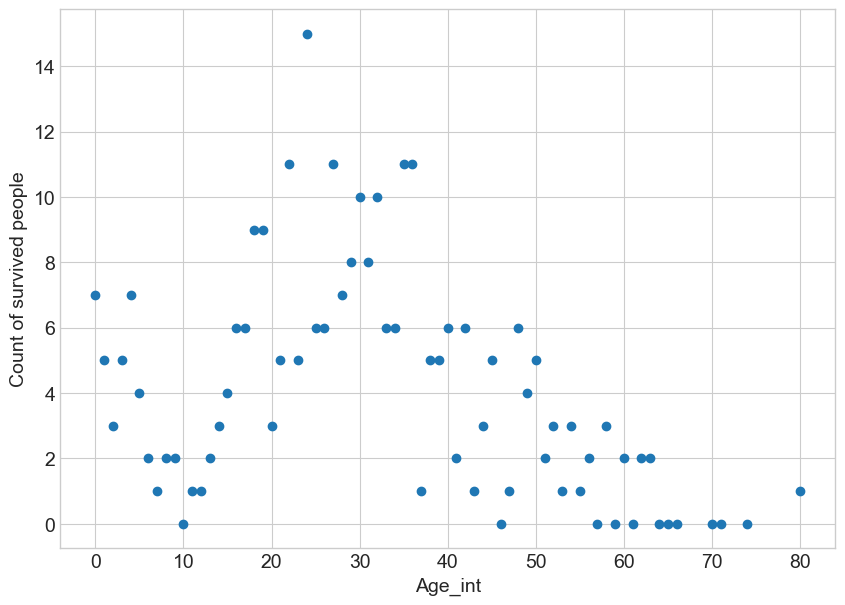

In [13]:
plt.figure(figsize=(10,7))

plt.scatter(x=data.Age_int, y=data.Survived)

plt.xlabel("Age_int")
plt.ylabel("Count of survived people")

plt.show()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


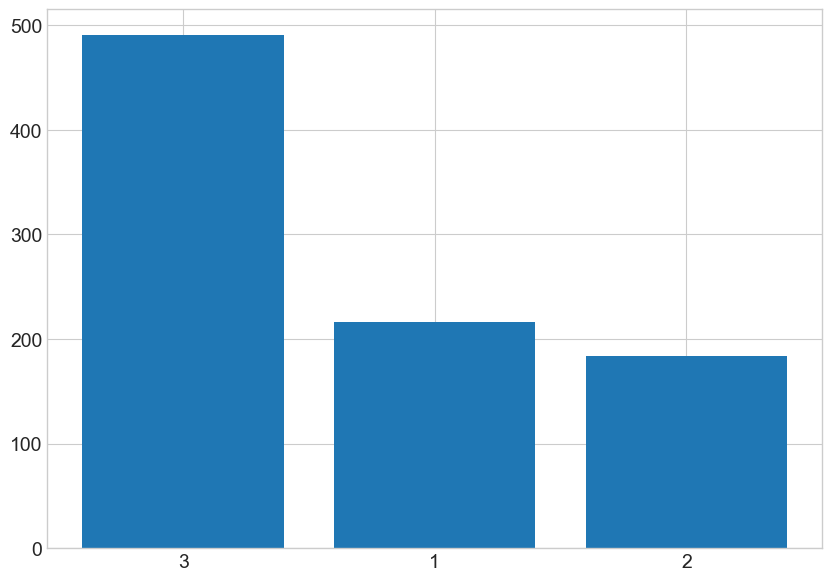

In [14]:
print(train_data.Pclass.value_counts())

plt.figure(figsize=(10,7))

plt.bar(x=train_data.Pclass.value_counts().index, height=train_data.Pclass.value_counts().values)

plt.show()

<Axes: >

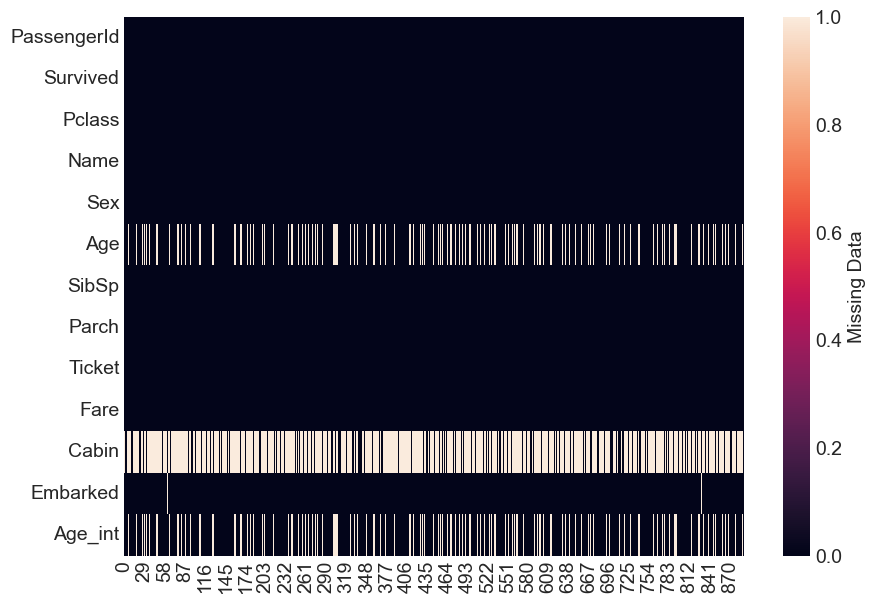

In [15]:
plt.figure(figsize=(10,7))

sns.heatmap(train_data.isna().transpose(), cbar_kws={"label": "Missing Data"})

In [16]:
train_data_num_features = train_data.select_dtypes(include=["float16","float32", "float64"])
train_data_num_features.drop("Age_int", axis=1, inplace=True)
train_data_num_features

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


<Figure size 1000x700 with 0 Axes>

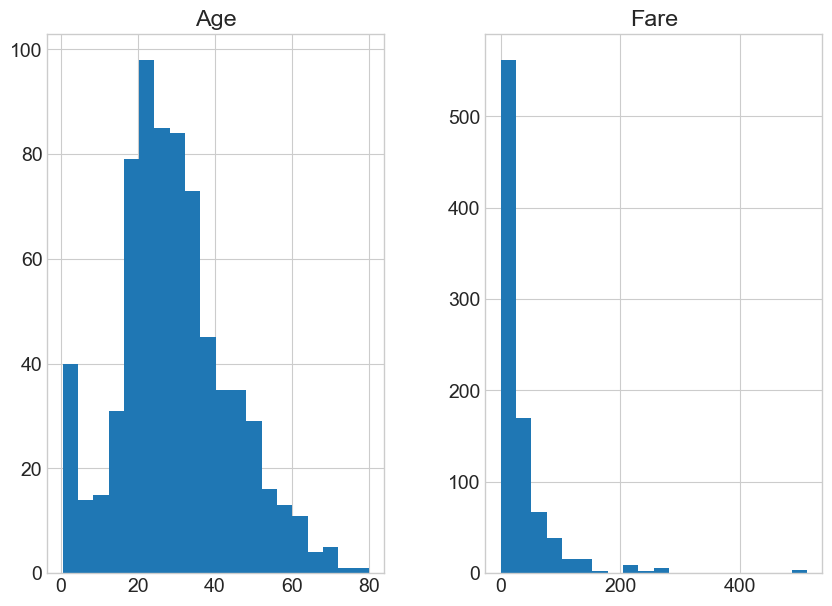

In [17]:
plt.figure(figsize=(10,7))

# sns.displot(train_data_num_features.Age, bins=20)
# sns.displot(train_data_num_features.Fare, bins=20)
train_data_num_features.hist(figsize=(10,7), bins=20, grid=True)

plt.show()

<Axes: >

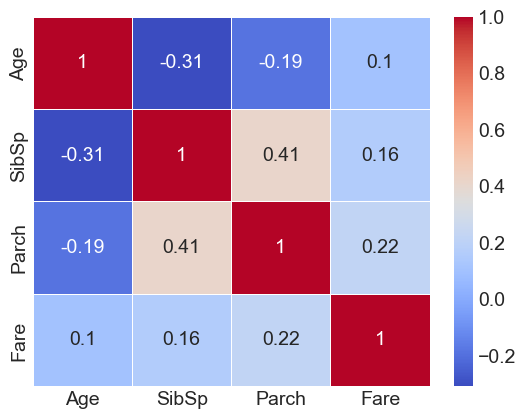

In [18]:

predictors = [ 'Age', 'SibSp', 'Parch', 'Fare']

corr_matrix = train_data[predictors].corr()
corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.1] = 0


sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap="coolwarm")

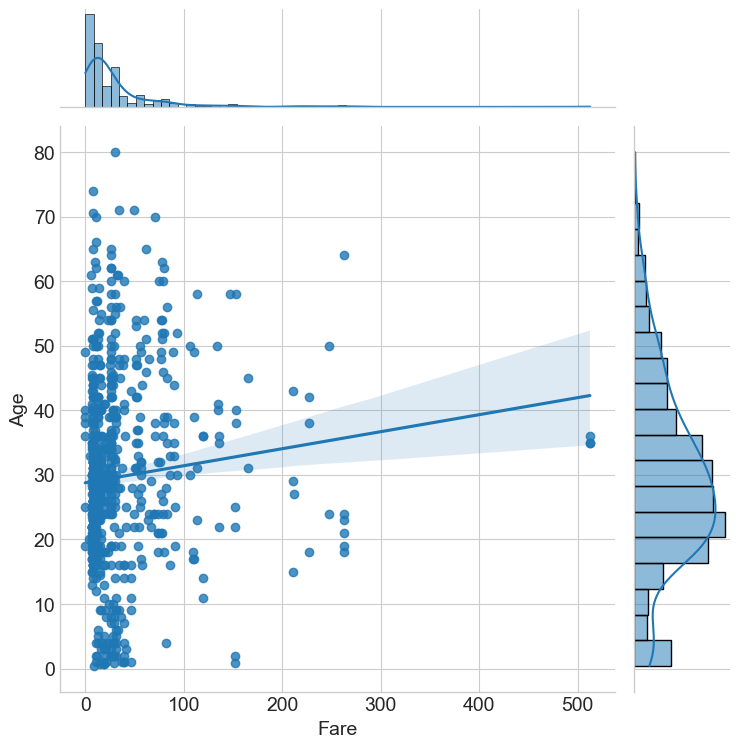

In [19]:
grid = sns.jointplot(y=train_data.Age, x=train_data.Fare, kind="reg")
grid.fig.set_figwidth(8)
grid.fig.set_figheight(8)

plt.show()

In [20]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Age_int      714 non-null    float64
dtypes: float64(3), int64(4), object(6)
memory usage: 90.6+ KB


In [35]:
row = train_data.Cabin.isna().sum()
cabin_counts = train_data.Cabin.value_counts()

cabin_counts.loc["NaN_str"] = row

cabin_counts

Cabin
B96 B98          4
G6               4
C23 C25 C27      4
C22 C26          3
F33              3
              ... 
C7               1
C54              1
E36              1
C148             1
NaN_str        687
Name: count, Length: 148, dtype: int64

In [36]:
pd.DataFrame(cabin_counts)

,count
Cabin,
B96 B98,4
G6,4
C23 C25 C27,4
C22 C26,3
F33,3
...,...
C7,1
C54,1
E36,1
